### Imports

In [1]:
# Imports
import torch
from typing import List, Tuple
from dataclasses import dataclass
import signatory

import numpy as np
import torch
import pickle
import os
from pathlib import Path
import bz2
import pandas as pd
import plotly.io as pio
pio.templates.default = 'plotly_white'
from minisom import MiniSom
from collections import Counter
from datetime import datetime
from statsmodels.tsa.arima_process import ArmaProcess
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,accuracy_score,jaccard_score
from scipy.optimize import linear_sum_assignment
from sklearn.linear_model import Lasso
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
import sys
# This is need to get the imports from SIGSOM and jump-models
sys.path.insert(0, os.path.abspath('../'))
# helper functions
from SIGSOM.sigsom.utils.helpers import logger, SOMParams
# signature transforms
import SIGSOM.sigsom.signatures.signature_transforms as st
# som
from SIGSOM.sigsom.som.som import SOM
from SIGSOM.sigsom.som.som_mahalanobis import SOMM
from SIGSOM.sigsom.som.adapted_som import GSOMM

from sklearn.preprocessing import PowerTransformer, MinMaxScaler


In [2]:
def rolling_window1(x: torch.Tensor, window: int) -> torch.Tensor:
    N = (x.shape[0]-1) // (window-1)
    result = torch.empty((N, window, x.shape[1]))
    for i in range(N):
        if i == 0:
            result[i, :, :] = x[0:window, :]
        else:
            result[i, :, :] = x[(i*(window))-i: (window*(i+1))-i,:]

    return result

In [3]:
import os
import numpy as np
import torch
import pandas as pd
from datetime import datetime
from pandas.tseries.offsets import DateOffset

# === Load and preprocess Bitcoin data ===
file_path = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\data\ohlcv_data\ohlcv_data\ohlcv_data\hdp_rest_INVERSE_PERPETUAL_BINANCE_INVERSE_PERPETUAL_BTC-USD_20220101_20231006.pbz2"

# Assuming 'st.load_pbz2' is a function to load compressed data
raw_data = st.load_pbz2(file_path)

# Ensure 'datetime' is a column and timezone-aware (use tz_convert directly)
raw_data['datetime'] = raw_data.index.tz_convert("America/New_York")

# Extract "Close" prices and convert to Tensor
data = raw_data[['close']].values
data = torch.tensor(data, dtype=torch.float32)

# === Load AAPL data from parquet files ===
folder_path = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\data\parquet_files"
folder_files = os.listdir(folder_path)
parquet_files = [f for f in folder_files if f.endswith('.parquet')]

stock_dict = {}
for file in parquet_files:
    file_path = os.path.join(folder_path, file)
    df_name = os.path.splitext(file)[0]
    stock_dict[df_name] = pd.read_parquet(file_path)

# Convert AAPL datetime to pandas Timestamp (ensure timezone is New York)
aapl_dates = pd.to_datetime(stock_dict["AAPL_full_1min_adjsplit"]["datetime"]).dt.tz_localize("America/New_York")

# Ensure BTC timestamps are also in "America/New_York" time zone
btc_dates = raw_data["datetime"]

# === Align time windows between BTC and AAPL ===
common_start_date = max(aapl_dates.min(), btc_dates.min())

# Ensure `common_start_date` is timezone-aware
common_start_date = common_start_date.tz_convert("America/New_York")

# If `common_start_date` is not in AAPL, find the next closest timestamp
if common_start_date not in aapl_dates.values:
    common_start_date = aapl_dates[aapl_dates > common_start_date].min()

print(f"Aligned start date: {common_start_date}")

# === Define resampling function ===
def resample_data(data, resample_rule='5T', start_date=None, end_offset_years=2, price_column='close'):
    """Resample data to a lower frequency and align with a given start date."""
    data = data.copy()
    data['datetime'] = pd.to_datetime(data['datetime'])

    # Ensure datetime is set as index
    data.set_index('datetime', inplace=True)

    # Convert index to timezone-aware if not already
    if data.index.tz is None:
        data.index = data.index.tz_localize("America/New_York")

    # Convert start date to timezone-aware if needed
    if start_date.tz is None:
        start_date = start_date.tz_localize("America/New_York")

    # Calculate end date based on start date + offset
    end_date = start_date + DateOffset(years=end_offset_years)

    # Filter based on start and end dates
    data = data.loc[start_date:end_date]

    # Resample to required frequency
    resampled_data = data.resample(resample_rule).agg({price_column: 'last'})

    # Handle missing values with forward fill
    resampled_data.ffill(inplace=True)

    return resampled_data

# === Resample AAPL and Bitcoin data ===
start_date = common_start_date

resampled_aapl = resample_data(stock_dict["AAPL_full_1min_adjsplit"], start_date=start_date)
resampled_aapl = resampled_aapl.iloc[:-1]  # Remove last row for alignment

resampled_btc = resample_data(raw_data, start_date=start_date, price_column='close')

# === Print sample output ===
print("Resampled AAPL data:")
print(resampled_aapl.head(10))

print("\nResampled Bitcoin data:")
print(resampled_btc.head(10))


Aligned start date: 2022-01-03 04:00:00-05:00
Resampled AAPL data:
                            close
datetime                         
2022-01-03 04:00:00-05:00  178.15
2022-01-03 04:05:00-05:00  177.99
2022-01-03 04:10:00-05:00  178.08
2022-01-03 04:15:00-05:00  177.86
2022-01-03 04:20:00-05:00  178.00
2022-01-03 04:25:00-05:00  177.82
2022-01-03 04:30:00-05:00  177.85
2022-01-03 04:35:00-05:00  177.77
2022-01-03 04:40:00-05:00  177.89
2022-01-03 04:45:00-05:00  178.01

Resampled Bitcoin data:
                             close
datetime                          
2022-01-03 04:00:00-05:00  47063.2
2022-01-03 04:05:00-05:00  47024.8
2022-01-03 04:10:00-05:00  46952.4
2022-01-03 04:15:00-05:00  46795.2
2022-01-03 04:20:00-05:00  46833.6
2022-01-03 04:25:00-05:00  46796.3
2022-01-03 04:30:00-05:00  46823.9
2022-01-03 04:35:00-05:00  46885.3
2022-01-03 04:40:00-05:00  46874.2
2022-01-03 04:45:00-05:00  46912.0


In [4]:
common_start_date

Timestamp('2022-01-03 04:00:00-0500', tz='America/New_York')

In [5]:
import os
import pandas as pd
import torch
import pandas as pd
from datetime import datetime

# Load the BTC data and process
file_path = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\data\ohlcv_data\ohlcv_data\ohlcv_data\hdp_rest_INVERSE_PERPETUAL_BINANCE_INVERSE_PERPETUAL_BTC-USD_20220101_20231006.pbz2"
raw_data = st.load_pbz2(file_path)
raw_data['datetime'] = raw_data.index

# Remove timezone info if exists, and localize to UTC for BTC
raw_data['datetime'] = raw_data['datetime'].dt.tz_convert('America/New_York')

# Extract "Close" data
data = raw_data[["close"]]
data = torch.tensor(data.values, dtype=torch.float32)

# Apple Stock Data Processing
folder_path = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\data\parquet_files"
folder_files = os.listdir(folder_path)
parquet_files = [f for f in folder_files if f.endswith('.parquet')]

stock_dict = {}
for file in parquet_files:
    file_path = os.path.join(folder_path, file)
    df_name = os.path.splitext(file)[0] 
    stock_dict[df_name] = pd.read_parquet(file_path)  

# Handle Apple (AAPL) Timezone and ensure it's in America/New_York
aapl_dates = pd.to_datetime(stock_dict["AAPL_full_1min_adjsplit"]["datetime"])
aapl_dates = aapl_dates.dt.tz_localize("America/New_York")
stock_dict["AAPL_full_1min_adjsplit"]["datetime"] = pd.to_datetime(stock_dict["AAPL_full_1min_adjsplit"]["datetime"])

# Step 2: Localize the datetime column to America/New_York
stock_dict["AAPL_full_1min_adjsplit"]["datetime"] = stock_dict["AAPL_full_1min_adjsplit"]["datetime"].dt.tz_localize("America/New_York")
# Convert Bitcoin (BTC) timestamps to America/New_York
btc_dates = raw_data['datetime'].dt.tz_convert("America/New_York")

# Find the common start date between the two datasets
common_start_date = max(aapl_dates[0], btc_dates[0])

if common_start_date not in aapl_dates.values:
    common_start_date = aapl_dates[aapl_dates > common_start_date].min()

# Function to Resample Data
def resample_data(data, resample_rule='5T', start_date=None, end_offset_years=2, price_column='close'):
    data['datetime'] = pd.to_datetime(data['datetime'])
    data.set_index('datetime', inplace=True)
    
    end_date = pd.to_datetime(start_date) + pd.DateOffset(years=end_offset_years)
    
    # Filter and Resample Data
    data = data.loc[start_date:end_date]
    resampled_data = data.resample(resample_rule).agg({price_column: 'last'})
    
    # Handle missing data with forward fill
    resampled_data.ffill(inplace=True)
    return resampled_data

# Use common start date and resample for 2 years
start_date = common_start_date

# Resample Apple and Bitcoin Data
resampled_aapl = resample_data(stock_dict["AAPL_full_1min_adjsplit"], start_date=start_date)
resampled_aapl = resampled_aapl.iloc[:-1]

resampled_btc = resample_data(raw_data, start_date=start_date, price_column='close')

# Display the results
print("Resampled AAPL Data:")
print(resampled_aapl.head(10))

print("\nResampled Bitcoin Data:")
print(resampled_btc.head(10))


Resampled AAPL Data:
                            close
datetime                         
2022-01-03 04:00:00-05:00  178.15
2022-01-03 04:05:00-05:00  177.99
2022-01-03 04:10:00-05:00  178.08
2022-01-03 04:15:00-05:00  177.86
2022-01-03 04:20:00-05:00  178.00
2022-01-03 04:25:00-05:00  177.82
2022-01-03 04:30:00-05:00  177.85
2022-01-03 04:35:00-05:00  177.77
2022-01-03 04:40:00-05:00  177.89
2022-01-03 04:45:00-05:00  178.01

Resampled Bitcoin Data:
                             close
datetime                          
2022-01-03 04:00:00-05:00  47063.2
2022-01-03 04:05:00-05:00  47024.8
2022-01-03 04:10:00-05:00  46952.4
2022-01-03 04:15:00-05:00  46795.2
2022-01-03 04:20:00-05:00  46833.6
2022-01-03 04:25:00-05:00  46796.3
2022-01-03 04:30:00-05:00  46823.9
2022-01-03 04:35:00-05:00  46885.3
2022-01-03 04:40:00-05:00  46874.2
2022-01-03 04:45:00-05:00  46912.0


In [6]:
import torch
resampled_stock_dict ={}
# Add Bitcoin and AAPL to the dictionary
resampled_stock_dict["BTC"] = resampled_btc  # Add resampled Bitcoin data to the stock dictionary for processing
resampled_stock_dict["AAPL"] = resampled_aapl  # Corrected spelling of "AAPL"

# Define the window size (assuming 96 intervals per day, for 10 days)
window_size = 96 * 10  # 10 days of 5-minute intervals

# Loop over both stock and Bitcoin data
for stock_name, stock_data in resampled_stock_dict.items():
    print(f"Processing: {stock_name}")
    
    # Check if stock_data is a DataFrame (not yet converted to Tensor)
    if isinstance(stock_data, pd.DataFrame):
        # Select the 'close' or 'price' column (assuming price column for Bitcoin is named 'price')
        if 'close' in stock_data.columns:
            data = stock_data[["close"]]
        elif 'price' in stock_data.columns:
            data = stock_data[["price"]]
        else:
            raise ValueError(f"No 'close' or 'price' column found in {stock_name} data.")
        
        # Convert to a numpy array
        data = data.values
        
        # Convert to a PyTorch Tensor
        data = torch.tensor(data, dtype=torch.float32)
    
    # Get 5-minute data (if no further reshaping or averaging is needed)
    data_5min1 = data
    
    # Reshape and prepare subwindows using rolling window (assuming window size for 10 days)
    data_5min_1 = rolling_window1(data_5min1, window=window_size)
    
    # Normalize each window by subtracting the first element and dividing by the standard deviation
    data_5min_1 = data_5min_1 - data_5min_1[:, 0:1]  # Subtract the first element of each window
    
    # Calculate standard deviation for each window, with a safeguard for zero std dev
    std_dev = torch.std(data_5min_1, dim=1, keepdim=True)
    
    # Replace zero standard deviations with 1 to avoid division by zero
    std_dev[std_dev == 0] = 1.0
    
    # Perform normalization
    data_5min_1 /= std_dev
    
    # Store the processed data back into the dictionary
    resampled_stock_dict[stock_name] = data_5min_1

    # Display processed data shape for debugging
    print(f"Processed data for {stock_name}: {data_5min_1.shape}")


Processing: BTC
Processed data for BTC: torch.Size([192, 960, 1])
Processing: AAPL
Processed data for AAPL: torch.Size([219, 960, 1])


In [7]:
multivariate_path=torch.cat([resampled_stock_dict["AAPL"][:192],resampled_stock_dict["BTC"][:]], dim=2)
multivariate_path.shape




torch.Size([192, 960, 2])

In [8]:
# Calculate the global minimum and maximum across all paths and time steps for each feature
data_min = multivariate_path.min(dim=0, keepdim=True)[0].min(dim=1, keepdim=True)[0]  # Global minimum per feature
data_max = multivariate_path.max(dim=0, keepdim=True)[0].max(dim=1, keepdim=True)[0]  # Global maximum per feature

# Apply Min-Max scaling: (data - min) / (max - min)
scaled_data = (multivariate_path - data_min) / (data_max - data_min)

# Check the range of the scaled data to confirm it's between 0 and 1
scaled_data_min = scaled_data.min().item()
scaled_data_max = scaled_data.max().item()

scaled_data_min, scaled_data_max


(0.0, 1.0)

In [9]:

# Augmentations
augmentations = [
    # (st.time_embedding, {'steps': "scale"}),
    # (st.time_transform, {'steps': "scale"}),
    # (st.cat_lags, {"m": 2}),
    # (st.cum_sum, {'dim': 1}),
    (st.lead_lag_transform, {}),
    # (st.lead_lag_transform, {}),
]
# Tranforms
transforms = [(st.log_singature  , {"depth": 3, "basepoint": False})         
]# , (st.signature, {"depth": 1, "basepoint": True})
# Pipleine
def apply_pipeline(data, augmentations, transforms):
    results = {}
    for func, kwargs in augmentations:
        aug = func(data, **kwargs)
        for trans,kwargs in transforms:
            sig = trans(aug, **kwargs)
            print(np.isnan(sig).any())
            if isinstance(func, tuple):
                key = f"{func[0].__name__}_{trans.__name__}"
            else:
                key = f"{func.__name__}_{trans.__name__}"

            results[key] = sig
    return results

results = apply_pipeline(multivariate_path[:800], augmentations, transforms)
print(results["lead_lag_transform_log_singature"].shape)

tensor(0, dtype=torch.uint8)
torch.Size([192, 30])


In [10]:
import torch
import math
import math
from sympy import mobius, divisors

# Augmentations
augmentations = [
    (st.lead_lag_transform, {}),
]

# Transforms
transforms = [(st.log_singature, {"depth": 3, "basepoint": False})]

# Function to calculate the number of terms at a given depth
# def num_terms_at_depth(dimension, depth):
#     """
#     Compute the number of signature terms at a given depth.
#     Args:
#     - dimension: The number of input dimensions (e.g., 6).
#     - depth: The signature depth.

#     Returns:
#     - Number of signature terms at that depth.
#     """
#     from math import comb  # Python 3.8+ has the comb function for combinatorics
#     return comb(dimension + depth - 1, depth)

def num_terms_at_depth(d, n):
    """
    Compute the number of terms in the log signature at depth n using the given formula.
    
    Args:
    - d: Dimension of the input path.
    - n: Depth level.

    Returns:
    - Number of log signature terms at depth n.
    """
    result = 0
    for m in divisors(n):
        result += mobius(m) * d**(n // m)
    return result // n

# Function to rescale signature terms by the factorial of the depth level
def rescale_signature_by_factorial(signature, dimension, depth):
    """
    Multiplies the terms in the signature by the factorial of their respective depth level.
    Args:
    - signature: The signature tensor.
    - dimension: The number of input dimensions.
    - depth: The maximum depth of the signature.

    Returns:
    - Rescaled signature (factorial-weighted by depth level).
    """
    rescaled_signature = []

    current_index = 0

    for d in range(1, depth + 1):
        # Calculate the number of terms at this depth level
        n_terms_at_depth_d = num_terms_at_depth(dimension, d)

        # Compute factorial of the current depth level
        depth_factorial = math.factorial(d)

        # Extract the terms for the current depth and multiply by the depth factorial
        terms_at_depth_d = signature[..., current_index:current_index + n_terms_at_depth_d] * depth_factorial

        # Append the rescaled terms to the rescaled_signature list
        rescaled_signature.append(terms_at_depth_d)

        # Update the index
        current_index += n_terms_at_depth_d

    # Concatenate rescaled terms along the feature dimension
    return torch.cat(rescaled_signature, dim=-1)

# Pipeline function
def apply_pipeline(data, augmentations, transforms):
    results = {}
    for func, kwargs in augmentations:
        aug = func(data, **kwargs)  # Apply augmentation
        for trans, trans_kwargs in transforms:
            sig = trans(aug, **trans_kwargs)  # Apply transformation (e.g., log signature)

            # Rescale the signature terms by depth factorial on the feature dimension (not the batch)
            depth = trans_kwargs["depth"]
            dimension = aug.shape[1]  # Number of input dimensions (e.g., 6)
            rescaled_sig = rescale_signature_by_factorial(sig, dimension, depth)

            # Generate key for storing results
            if isinstance(func, tuple):
                key = f"{func[0].__name__}_{trans.__name__}"
            else:
                key = f"{func.__name__}_{trans.__name__}"

            results[key] = rescaled_sig

    return results

# Example usage with multivariate path (6-dimensional tensor)
# Assuming multivariate_path is a tensor of shape [8000, 6]

# Apply the pipeline
results1 = apply_pipeline(multivariate_path[:8000], augmentations, transforms)

# Print the shape of the rescaled signature output
print(results1["lead_lag_transform_log_singature"].shape)


torch.Size([192, 30])


In [11]:
results1["lead_lag_transform_log_singature"].shape

torch.Size([192, 30])

In [12]:
torch.save(results1["lead_lag_transform_log_singature"], "scaled_BTC_AAPL_close")
print(results1["lead_lag_transform_log_singature"].shape)

torch.Size([192, 30])


### Fit

In [13]:
# Function to calculate VIF
def calculate_vif(x):
    vif = [variance_inflation_factor(x.cpu().numpy(), i) for i in range(x.shape[1])]
    return torch.tensor(vif)

# Function to remove features with high VIF
def remove_vif(x, threshold=10):
    while True and x.shape[1] > 1:
        vif = calculate_vif(x)
        max_vif = torch.max(vif)  # check if largest value below threshold
        if max_vif <= threshold:
            break
        feature_to_remove = torch.argmax(vif)  # get index
        x = torch.cat((x[:, :feature_to_remove], x[:, feature_to_remove + 1:]), dim=1)  # remove highest vif
    return x

vif_cleaned_result = remove_vif(results["lead_lag_transform_log_singature"], threshold=10)

In [14]:
print(vif_cleaned_result.shape)

torch.Size([192, 12])


In [16]:
# vif_cleaned_results = torch.load("vif_cleaned_results.pt")
#torch.tensor(reduced_data, dtype=torch.float32)
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA

# create classes


# pca = PCA(n_components=2)
# train_matrix = pca.fit_transform(vif_cleaned_results[0])
# scaler = RobustScaler()
# train_matrix = scaler.fit_transform(vif_cleaned_results[0])
# scaler = PowerTransformer(method='yeo-johnson',standardize=True)
# train_matrix = scaler.fit_transform(vif_cleaned_results[0])

# scaler = RobustScaler()
# # data_scaled = scaler.fit_transform(vif_cleaned_results[0])
# # scaler = MinMaxScaler(feature_range=(-1, 1))
# data_scaled = scaler.fit_transform(vif_cleaned_results[0])
# scaler = StandardScaler()
# data_scaled = scaler.fit_transform(data_scaled)
scaler = PowerTransformer(method='yeo-johnson',standardize=True)
data_scaled = scaler.fit_transform(vif_cleaned_result[:100,:])#[:,[0,1,2]])


scaler = MinMaxScaler(feature_range=(-1, 1))
train_matrix = scaler.fit_transform(data_scaled)

# train_matrix = np.log(mean_tensor)

# column_to_scale = train_matrix[:, 1].reshape(-1, 1) 
# scaler = MinMaxScaler(feature_range=(-1, 1000))
# scaled_column = scaler.fit_transform(column_to_scale)
# train_matrix[:, 1] = scaled_column.flatten()  
# # # Apply the scaling


train_matrix1 = torch.tensor(data_scaled, dtype=torch.float32)

# params = SOMParams(map_size= (2, 1),input_dims=train_matrix1.shape[1], lr = .3, dump_path=str(r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Simulations\results"))
# som = SOMM(logger = logger, params = params)
# som.initialize(train_matrix1)
# t0 = datetime.now()
# Fit Model
# som.fit(X_train=train_matrix1, X_val=None, iterations=1000, Tmax=10, Tmin=1)# 2, 0.2
# # Predict
# preds1 = som.predict(x=train_matrix1)


# # Hirarcical som for 4 clusters tmax 5 tmin .3 , itaration 300, lr .3
params = SOMParams(map_size=(2, 1),Tmax=7,Tmin=.01,batch_size = 512,iterations = 1000, input_dims=train_matrix1.shape[1], lr=0.001, dump_path=str(r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Simulations\results"))
gsomm = GSOMM(logger=logger, params=params)
gsomm.somm.initialize(train_matrix1)
t0 = datetime.now()

inital_preds2, initial_quantization_error = gsomm.initial_train(X_train=train_matrix1)

2025-02-17 22:32:08,326     adapted_som INFO     MainThread   MainProcess Training Initial SOMM
2025-02-17 22:32:08,327     adapted_som INFO     MainThread   MainProcess Save interval: 50
c:\Users\frede\anaconda3\envs\SIGSOM_v1\lib\site-packages\torch\_tensor.py:575: UserWarning: floor_divide is deprecated, and will be removed in a future version of pytorch. It currently rounds toward 0 (like the 'trunc' function NOT 'floor'). This results in incorrect rounding for negative values.
To keep the current behavior, use torch.div(a, b, rounding_mode='trunc'), or for actual floor division, use torch.div(a, b, rounding_mode='floor'). (Triggered internally at  ..\aten\src\ATen\native\BinaryOps.cpp:467.)
  return torch.floor_divide(self, other)
2025-02-17 22:32:08,447     adapted_som INFO     MainThread   MainProcess Iteration 49 - T=N/A
2025-02-17 22:32:08,455     adapted_som INFO     MainThread   MainProcess   [Train] - L = 28.246, L_km = 12.246000289916992
2025-02-17 22:32:08,484     adapted

updated
tensor(12.2462)


2025-02-17 22:32:12,468     adapted_som INFO     MainThread   MainProcess Iteration 99 - T=N/A
2025-02-17 22:32:12,468     adapted_som INFO     MainThread   MainProcess   [Train] - L = 26.11, L_km = 11.892999649047852
2025-02-17 22:32:12,468     adapted_som INFO     MainThread   MainProcess   [Train] - L = 26.11, som_loss = 26.110000610351562


tensor(11.8933)


2025-02-17 22:32:12,818     adapted_som INFO     MainThread   MainProcess Iteration 149 - T=N/A
2025-02-17 22:32:12,818     adapted_som INFO     MainThread   MainProcess   [Train] - L = 24.266, L_km = 11.73799991607666
2025-02-17 22:32:12,831     adapted_som INFO     MainThread   MainProcess   [Train] - L = 24.266, som_loss = 24.266000747680664


...

tensor(11.2739)


2025-02-17 22:32:18,883     adapted_som INFO     MainThread   MainProcess Iteration 949 - T=N/A
2025-02-17 22:32:18,883     adapted_som INFO     MainThread   MainProcess   [Train] - L = 11.263, L_km = 11.262999534606934
2025-02-17 22:32:18,883     adapted_som INFO     MainThread   MainProcess   [Train] - L = 11.263, som_loss = 11.262999534606934


tensor(11.2628)


2025-02-17 22:32:19,217     adapted_som INFO     MainThread   MainProcess Iteration 999 - T=N/A
2025-02-17 22:32:19,217     adapted_som INFO     MainThread   MainProcess   [Train] - L = 11.254, L_km = 11.253999710083008
2025-02-17 22:32:19,217     adapted_som INFO     MainThread   MainProcess   [Train] - L = 11.254, som_loss = 11.253999710083008


tensor(11.2537)


In [17]:
import torch
from sklearn.preprocessing import MinMaxScaler, PowerTransformer
from datetime import datetime
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.decomposition import PCA


# Initializing variables to store the best model and the lowest quantization error
best_gsomm = None
lowest_quantization_error = float('inf')

# Perform the process 20 times
for i in range(20):
    print(f"Run {i+1}/20")

    # Preprocess the data
    scaler = PowerTransformer(method='yeo-johnson', standardize=True)
    data_scaled = scaler.fit_transform(vif_cleaned_result[:100,:])#[:,[0,1,2]])

    scaler = MinMaxScaler(feature_range=(-1, 1))
    train_matrix = scaler.fit_transform(data_scaled)

    train_matrix1 = torch.tensor(data_scaled, dtype=torch.float32)

    # Set SOM parameters
    params = SOMParams(map_size=(2, 1), Tmax=6, Tmin=.1, batch_size=512, iterations=1000,
                       input_dims=train_matrix1.shape[1], lr=0.01,
                       dump_path=r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Simulations\results")

    gsomm = GSOMM(logger=logger, params=params)
    gsomm.somm.initialize(train_matrix1)

    # Train the SOM and calculate quantization error
    inital_preds2, initial_quantization_error = gsomm.initial_train(X_train=train_matrix1)

    # Compare the quantization error to find the best model
    if initial_quantization_error < lowest_quantization_error:
        lowest_quantization_error = initial_quantization_error
        best_gsomm = gsomm
        print(f"New best model found with quantization error: {initial_quantization_error.item()}")

# Output the lowest quantization error and the best model
print(f"Lowest quantization error: {lowest_quantization_error.item()}")


2025-02-17 22:32:19,787     adapted_som INFO     MainThread   MainProcess Training Initial SOMM
2025-02-17 22:32:19,788     adapted_som INFO     MainThread   MainProcess Save interval: 50


Run 1/20
updated
tensor(11.7166)


2025-02-17 22:32:19,997     adapted_som INFO     MainThread   MainProcess Iteration 49 - T=N/A
2025-02-17 22:32:19,997     adapted_som INFO     MainThread   MainProcess   [Train] - L = 24.013, L_km = 11.717000007629395
2025-02-17 22:32:19,997     adapted_som INFO     MainThread   MainProcess   [Train] - L = 24.013, som_loss = 24.01300048828125
2025-02-17 22:32:20,371     adapted_som INFO     MainThread   MainProcess Iteration 99 - T=N/A
2025-02-17 22:32:20,373     adapted_som INFO     MainThread   MainProcess   [Train] - L = 23.108, L_km = 11.73799991607666
2025-02-17 22:32:20,374     adapted_som INFO     MainThread   MainProcess   [Train] - L = 23.108, som_loss = 23.107999801635742


tensor(11.7379)


2025-02-17 22:32:20,781     adapted_som INFO     MainThread   MainProcess Iteration 149 - T=N/A
2025-02-17 22:32:20,781     adapted_som INFO     MainThread   MainProcess   [Train] - L = 22.707, L_km = 11.784000396728516
2025-02-17 22:32:20,796     adapted_som INFO     MainThread   MainProcess   [Train] - L = 22.707, som_loss = 22.707000732421875


...

tensor(11.1566)


2025-02-17 22:34:58,399     adapted_som INFO     MainThread   MainProcess Iteration 949 - T=N/A
2025-02-17 22:34:58,401     adapted_som INFO     MainThread   MainProcess   [Train] - L = 11.157, L_km = 11.156999588012695
2025-02-17 22:34:58,402     adapted_som INFO     MainThread   MainProcess   [Train] - L = 11.157, som_loss = 11.156999588012695


tensor(11.1565)


2025-02-17 22:34:58,757     adapted_som INFO     MainThread   MainProcess Iteration 999 - T=N/A
2025-02-17 22:34:58,759     adapted_som INFO     MainThread   MainProcess   [Train] - L = 11.157, L_km = 11.156999588012695
2025-02-17 22:34:58,759     adapted_som INFO     MainThread   MainProcess   [Train] - L = 11.157, som_loss = 11.156999588012695


tensor(11.1565)
Lowest quantization error: 1106.193115234375


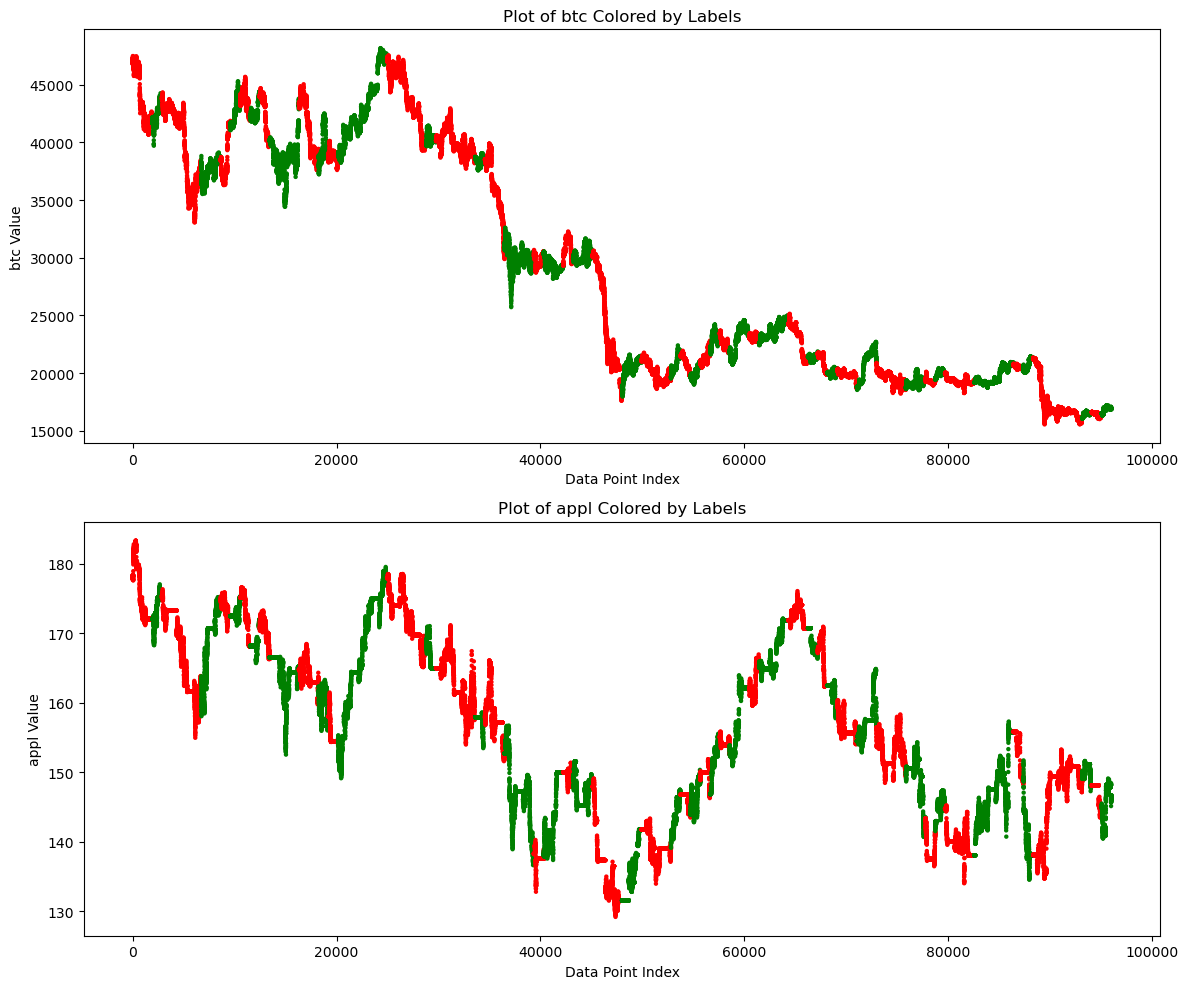

In [18]:
initial_preds_rep = np.repeat(inital_preds2.cpu(), 10*96)
initial_preds_rep.shape

import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Assuming initial_preds_rep is already defined and repeated correctly
a,qe,_ = best_gsomm.predict(train_matrix1)

initial_preds_rep = np.repeat(np.array(a).flatten(), 10*96)
# Assuming eth and btc data are already extracted
btc = resampled_btc.values[:96000, 0]
appl = resampled_aapl.values[:96000, 0]
# Define the custom colormap: red, blue, and green for your mapped labels
custom_cmap = ListedColormap(['green', 'red'])

# Create figure with two subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# Plot ETH in the top subplot
axs[0].scatter(np.arange(len(btc[:96000])), btc[:96000],
               c=initial_preds_rep[:96000], cmap=custom_cmap, s=10, alpha=1, edgecolor='none')
axs[0].set_title('Plot of btc Colored by Labels')
axs[0].set_xlabel('Data Point Index')
axs[0].set_ylabel('btc Value')

# Plot BTC in the bottom subplot
axs[1].scatter(np.arange(len(appl[:96000])), appl[:96000],
               c=initial_preds_rep[:96000], cmap=custom_cmap, s=10, alpha=1, edgecolor='none')
axs[1].set_title('Plot of appl Colored by Labels')
axs[1].set_xlabel('Data Point Index')
axs[1].set_ylabel('appl Value')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


### Plots

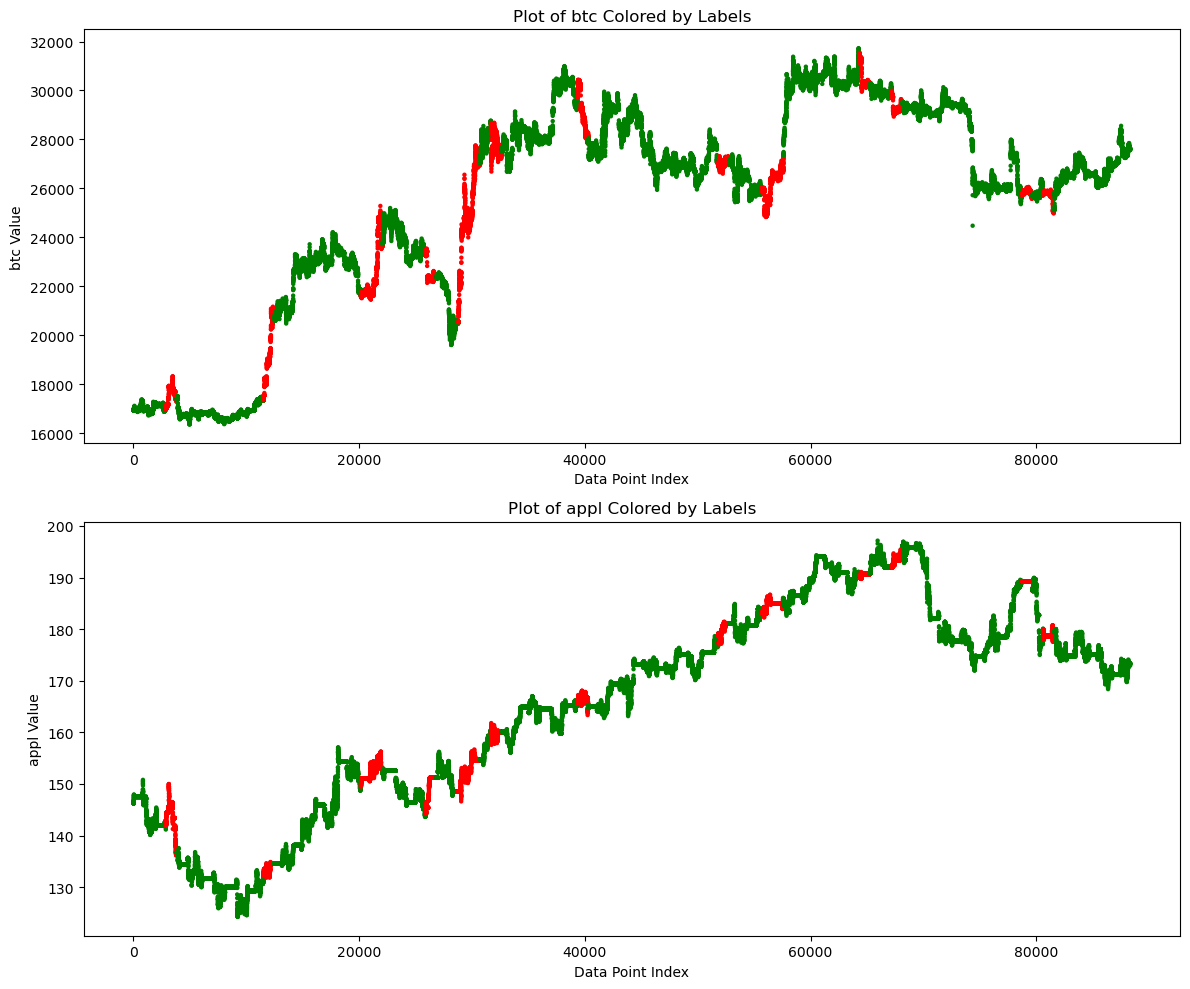

In [22]:
scaled_data = scaler.fit_transform(vif_cleaned_result[100:])
min_max_scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_data = min_max_scaler.fit_transform(scaled_data)
test_matrix = torch.tensor(scaled_data, dtype=torch.float32)

# # Step 3: Get predictions and quantization error
# test_preds, qe, proto = best_gsomm.predict(test_matrix)  # Replace 'gsomm.predict' with your method
# test_preds = np.array(test_preds).flatten()
initial_preds_rep = np.repeat(test_preds, 10*96)
initial_preds_rep.shape


import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


# Assuming eth and btc data are already extracted
btc = resampled_btc.values[96000:, 0]
appl = resampled_aapl.values[96000:, 0]
# Define the custom colormap: red, blue, and green for your mapped labels
custom_cmap = ListedColormap(['green', 'red'])

# Create figure with two subplots
fig, axs = plt.subplots(2, 1, figsize=(12, 10))

# Plot ETH in the top subplot
axs[0].scatter(np.arange(len(btc[:88320])), btc[:88320],
               c=initial_preds_rep[:], cmap=custom_cmap, s=10, alpha=1, edgecolor='none')
axs[0].set_title('Plot of btc Colored by Labels')
axs[0].set_xlabel('Data Point Index')
axs[0].set_ylabel('btc Value')

# Plot BTC in the bottom subplot
axs[1].scatter(np.arange(len(appl[:88320])), appl[:88320],
               c=initial_preds_rep[:], cmap=custom_cmap, s=10, alpha=1, edgecolor='none')
axs[1].set_title('Plot of appl Colored by Labels')
axs[1].set_xlabel('Data Point Index')
axs[1].set_ylabel('appl Value')

# Adjust layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()


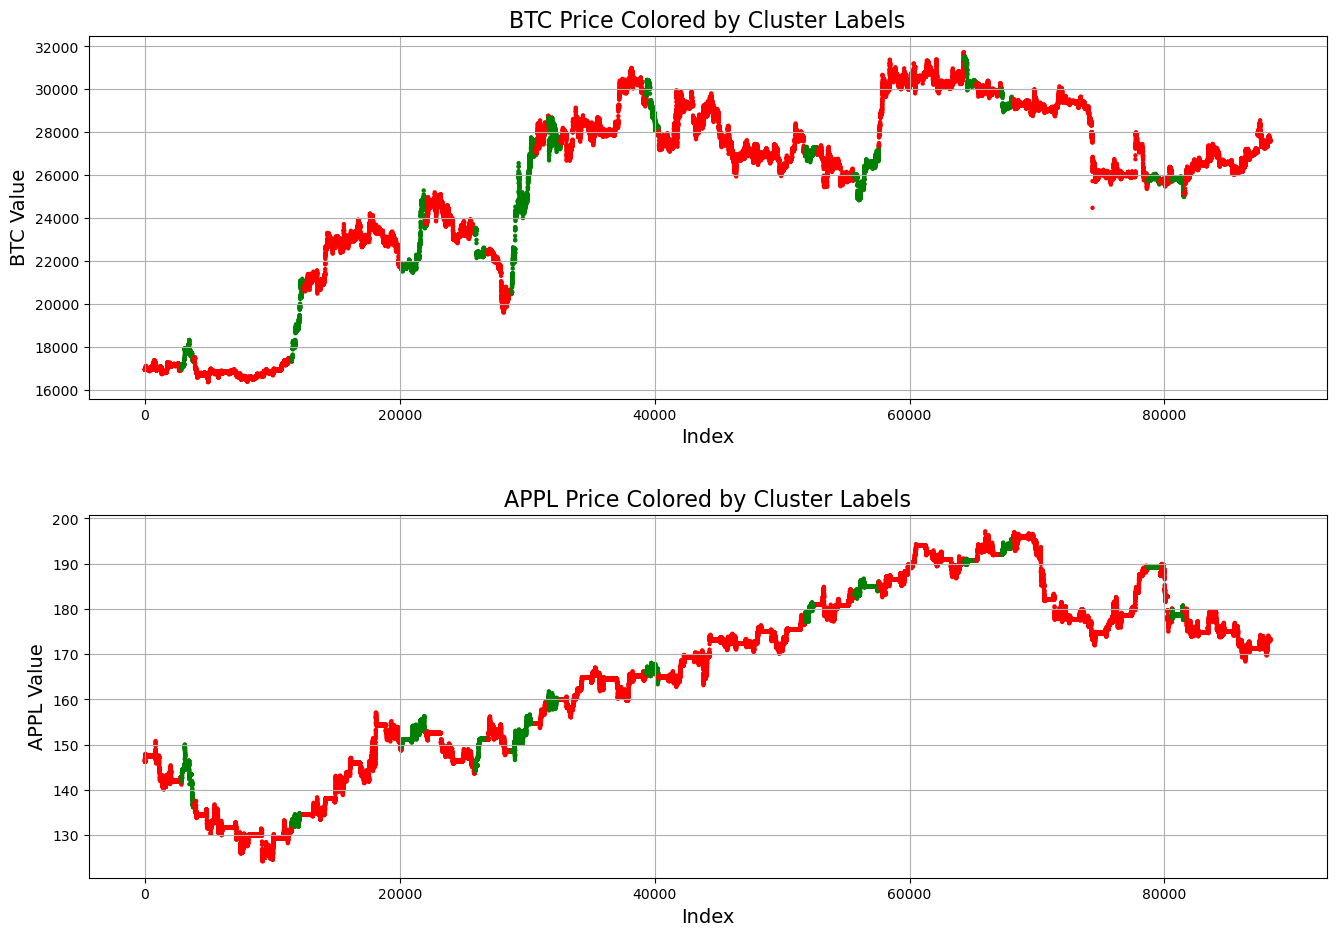

In [23]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Assuming btc and appl data are already extracted
btc = resampled_btc.values[96000:, 0]
appl = resampled_aapl.values[96000:, 0]

# Define the custom colormap: red for one label, green for another
custom_cmap = ListedColormap(['red', 'green'])

# Create figure with two subplots
fig, axs = plt.subplots(2, 1, figsize=(14, 10))  # Adjusted figure size to match Multivariate Crypto style

# Plot BTC in the top subplot
axs[0].scatter(np.arange(len(btc[:88320])), btc[:88320],
               c=initial_preds_rep[:], cmap=custom_cmap, s=10, alpha=1, edgecolor='none')
axs[0].set_title('BTC Price Colored by Cluster Labels', fontsize=16)
axs[0].set_xlabel('Index', fontsize=14)
axs[0].set_ylabel('BTC Value', fontsize=14)
axs[0].grid(True)  # Add grid

# Plot APPL in the bottom subplot
axs[1].scatter(np.arange(len(appl[:88320])), appl[:88320],
               c=initial_preds_rep[:], cmap=custom_cmap, s=10, alpha=1, edgecolor='none')
axs[1].set_title('APPL Price Colored by Cluster Labels', fontsize=16)
axs[1].set_xlabel('Index', fontsize=14)
axs[1].set_ylabel('APPL Value', fontsize=14)
axs[1].grid(True)  # Add grid

# Improve layout for better spacing
plt.tight_layout(pad=3.0)
plt.savefig("Mixed Data.png")
# Show the plot
plt.show()


In [ ]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D  # For creating custom legend entries

# Assuming btc and appl data are already extracted
btc = resampled_btc.values[96000:, 0]
appl = resampled_aapl.values[96000:, 0]

btc_dates = resampled_btc.index[96000:]

# Define the custom colormap: red for one label, green for another
custom_cmap = ListedColormap(['green', 'red'])

# Create figure with two subplots
fig, axs = plt.subplots(2, 1, figsize=(14, 10))  # Adjusted figure size to match Multivariate Crypto style

# Plot BTC as lines
axs[0].plot(btc_dates[:88320], btc[:88320], color='gray', alpha=0.4)  # Plot entire BTC data in light color
for i in range(len(btc[:88320]) - 1):
    axs[0].plot([btc_dates[i], btc_dates[i + 1]], [btc[i], btc[i + 1]], color=custom_cmap(initial_preds_rep[i]), alpha=0.7)

# Set title and labels for BTC
axs[0].set_title('BTC Price Colored by Cluster Labels', fontsize=18)
axs[0].set_ylabel('BTC Price', fontsize=16)
axs[0].grid(True)

# Plot APPL as lines
axs[1].plot(btc_dates[:88320], appl[:88320], color='gray', alpha=0.4)  # Plot entire APPL data in light color
for i in range(len(appl[:88320]) - 1):
    axs[1].plot([btc_dates[i], btc_dates[i + 1]], [appl[i], appl[i + 1]], color=custom_cmap(initial_preds_rep[i]), alpha=0.7)

# Set title and labels for APPL
axs[1].set_title('AAPL Price Colored by Cluster Labels', fontsize=18)
axs[1].set_xlabel('Date', fontsize=16)
axs[1].set_ylabel('AAPL Price', fontsize=16)
axs[1].grid(True)

# Create custom legend entries
legend_elements = [Line2D([0], [0], color='green', lw=4, label='Cluster 1'),
                   Line2D([0], [0], color='red', lw=4, label='Cluster 2')]

# Add the legend to the top subplot
axs[0].legend(handles=legend_elements, loc='upper left', fontsize=14)

# Rotate date labels for better readability
for ax in axs:
    ax.tick_params(axis='x', rotation=45)

# Improve layout for better spacing
plt.tight_layout(pad=3.0)

# Save the figure
output_path = r"C:\Users\frede\OneDrive\Desktop\Statistik Master\Semester 4\Thesis\Code\GitLab_Thesis\sigsom\codes\Pictures for Report\Mixed_Data.png"
plt.savefig(output_path)

# Show the plot
plt.show()
